In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/recipe-for-rating-predict-food-ratings-using-ml/sample.csv
/kaggle/input/recipe-for-rating-predict-food-ratings-using-ml/train.csv
/kaggle/input/recipe-for-rating-predict-food-ratings-using-ml/test.csv


<h1>Predicting Food Recipe Ratings</h1>

<h2>Loading and Understanding the data</h2>

In [2]:
#Importing Libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
#Loading the data
data=pd.read_csv("/kaggle/input/recipe-for-rating-predict-food-ratings-using-ml/train.csv")
data.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


In [4]:
#Finding the number of rows and columns present in the dataset
data.shape

(13636, 15)

<h5>The number of rows are 13,636 and the number of columns are 15.</h5>

In [5]:
#Summary statistics
data.describe(include='all')

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
count,13636.000000,13636.000000,13636.000000,13636,13636,13636,13636,13636.000000,1.363600e+04,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13634
unique,NaN,NaN,NaN,100,13636,10783,10620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13370
top,NaN,NaN,NaN,Cheeseburger Soup,sp_aUSaElGf_12259_c_149978,u_1oKVZoIOMWJ2j7TA7py2BIbf1mm,mjlouk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Delicious!
freq,NaN,NaN,NaN,553,1,20,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
mean,121.085289,38.624377,21785.990833,NaN,NaN,NaN,NaN,2.160311,1.623713e+09,0.014520,1.098269,0.543708,4.288721,153.127897,NaN
std,116.995633,29.672351,23883.189918,NaN,NaN,NaN,NaN,10.086424,5.444020e+06,0.137323,4.166487,3.265660,1.544839,140.986908,NaN
min,0.000000,1.000000,386.000000,NaN,NaN,NaN,NaN,0.000000,1.613035e+09,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,45.000000,12.000000,6504.000000,NaN,NaN,NaN,NaN,1.000000,1.622717e+09,0.000000,0.000000,0.000000,5.000000,100.000000,NaN
50%,91.000000,33.000000,14600.000000,NaN,NaN,NaN,NaN,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000,NaN
75%,148.000000,63.000000,33121.000000,NaN,NaN,NaN,NaN,1.000000,1.622718e+09,0.000000,0.000000,0.000000,5.000000,100.000000,NaN


In [6]:
#Information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13636 entries, 0 to 13635
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 13636 non-null  int64 
 1   RecipeNumber       13636 non-null  int64 
 2   RecipeCode         13636 non-null  int64 
 3   RecipeName         13636 non-null  object
 4   CommentID          13636 non-null  object
 5   UserID             13636 non-null  object
 6   UserName           13636 non-null  object
 7   UserReputation     13636 non-null  int64 
 8   CreationTimestamp  13636 non-null  int64 
 9   ReplyCount         13636 non-null  int64 
 10  ThumbsUpCount      13636 non-null  int64 
 11  ThumbsDownCount    13636 non-null  int64 
 12  Rating             13636 non-null  int64 
 13  BestScore          13636 non-null  int64 
 14  Recipe_Review      13634 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.6+ MB


In [7]:
#Finding the numerical variables in the dataset
data_types = data.dtypes
numerical_variables = data_types[data_types == 'int64'].index
print("Numerical Variables:")
print(numerical_variables)
print("Number of Numerical variables:",len(numerical_variables))

Numerical Variables:
Index(['ID', 'RecipeNumber', 'RecipeCode', 'UserReputation',
       'CreationTimestamp', 'ReplyCount', 'ThumbsUpCount', 'ThumbsDownCount',
       'Rating', 'BestScore'],
      dtype='object')
Number of Numerical variables: 10


In [8]:
#Finding the categorical variables in the dataset
data_types = data.dtypes
categorical_variables = data_types[data_types == 'object'].index
print("Categorical Variables:")
print(categorical_variables)
print("Number of Categorical variables:",len(categorical_variables))

Categorical Variables:
Index(['RecipeName', 'CommentID', 'UserID', 'UserName', 'Recipe_Review'], dtype='object')
Number of Categorical variables: 5


In [9]:
#Checking for missing values
data.isna().sum()

ID                   0
RecipeNumber         0
RecipeCode           0
RecipeName           0
CommentID            0
UserID               0
UserName             0
UserReputation       0
CreationTimestamp    0
ReplyCount           0
ThumbsUpCount        0
ThumbsDownCount      0
Rating               0
BestScore            0
Recipe_Review        2
dtype: int64

<h5>There exits two missing values in the "Recipe_Review" Column.</h5>

In [10]:
#Checking for duplicate entries
print("Number of duplicates present:",data.duplicated().sum())

Number of duplicates present: 0


In [11]:
check1=pd.DataFrame(data[data["UserName"] == "misscoffeepot"])
check1.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
4188,27,77,16458,Cherry Bars,sp_aUSaElGf_16458_c_384208,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622718272,0,7,0,5,390,Easier than cherry pie-! I really enjoy these...
5132,8,28,12734,Cheesy Ham Chowder,sp_aUSaElGf_12734_c_432373,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622648873,0,4,0,5,329,Excellent and easy! Chock full of flavor and ...
5329,64,33,32535,Creamy Grape Salad,sp_aUSaElGf_32535_c_270726,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717691,0,0,0,5,100,reminds me of cheesecake! I have a new potluc...
8081,268,2,3309,Best Ever Banana Bread,sp_aUSaElGf_3309_c_409865,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,1,1613039486,0,0,0,5,100,Really a nice recipe. My family cannot have n...


<h5>The User ID is unique to a particular user. But there are instances where there are user ids that have similar user names.</h5>

<h2>Exploratory Data Analysis</h2>

Class=5, n=10371 (76.056%)
Class=3, n=368 (2.699%)
Class=4, n=1241 (9.101%)
Class=0, n=1272 (9.328%)
Class=2, n=174 (1.276%)
Class=1, n=210 (1.540%)


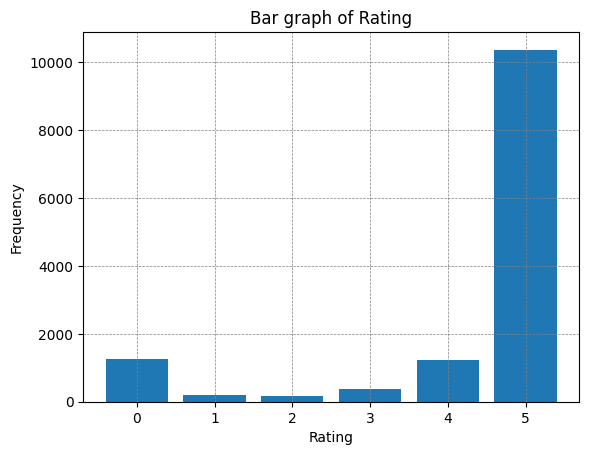

In [12]:
#Checking the distribution of the target variable "Rating"

#Utilising Label Encode on the targer variable
y=LabelEncoder().fit_transform(data["Rating"])

#Storing the class distribution of the target variable
counter=Counter(y)
#Finding the percentage of occurrence of each rating
for k,v in counter.items():
    p=v/len(y)*100
    print("Class=%d, n=%d (%.3f%%)" % (k,v,p))

#Plotting the bar graph to display the distribution of the target variable
plt.bar(counter.keys(),counter.values())
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.title("Bar graph of Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

<h5>The Rating '5' is occuring more number of times in comparison to other ratings. There exists a class imbalance.</h5>

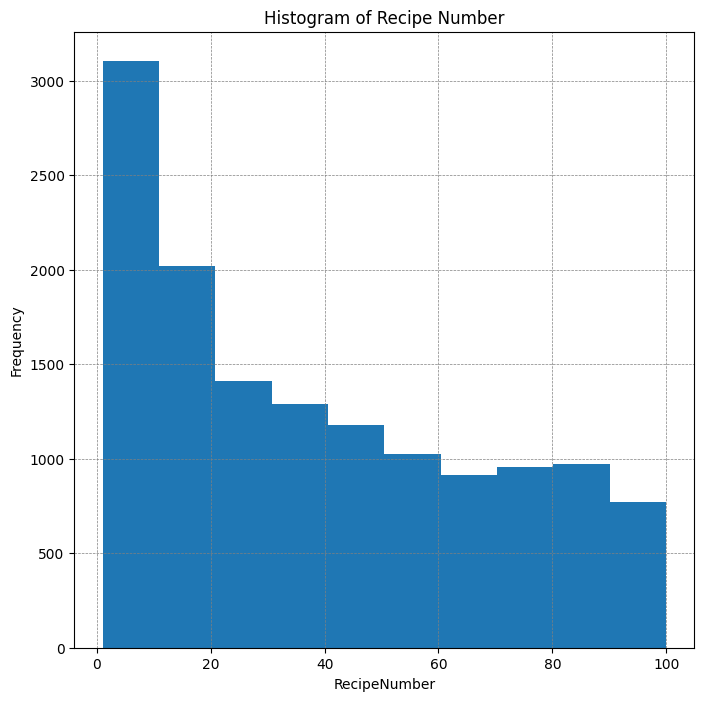

In [13]:
#Finding the number of a times a particular recipe has occurred in the dataset
data["RecipeNumber"].hist(figsize=(8,8))
plt.title("Histogram of Recipe Number")
plt.xlabel("RecipeNumber")
plt.ylabel("Frequency")
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.show()

<h5>The Recipe Numbers ranging from 0 to 10 is occurring more number of times in comparison with the other Recipe Numbers.</h5>

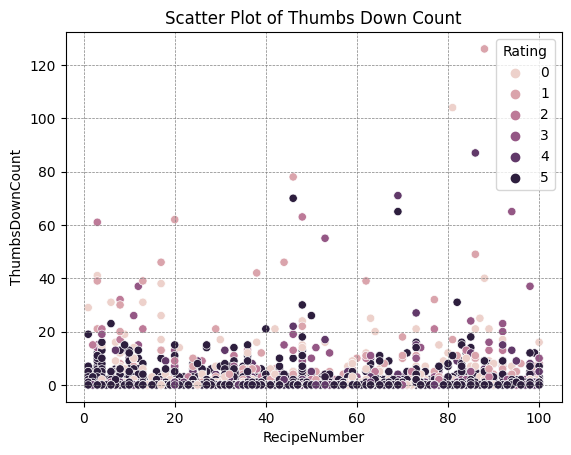

In [14]:
#Scatterplot of "ThumbsDownCount" against "RecipeNumber"
exploration_set1=data.copy()
sns.scatterplot(x="RecipeNumber",y="ThumbsDownCount",hue="Rating",data=exploration_set1)
plt.title('Scatter Plot of Thumbs Down Count')
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.show()

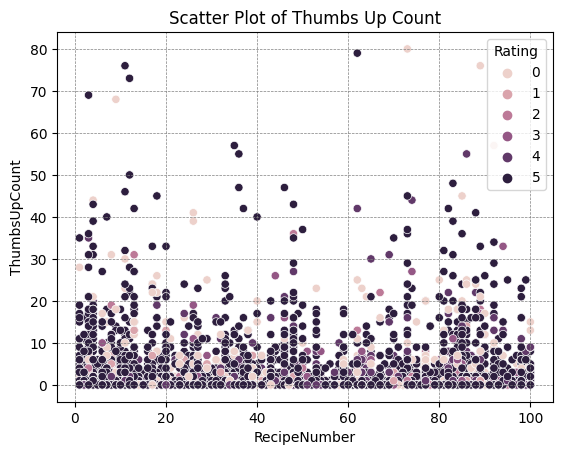

In [15]:
#Scatterplot of "ThumbsUpCount" against "RecipeNumber"
exploration_set2=data.copy()
sns.scatterplot(x="RecipeNumber",y="ThumbsUpCount",hue="Rating",data=exploration_set2)
plt.title('Scatter Plot of Thumbs Up Count')
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.show()

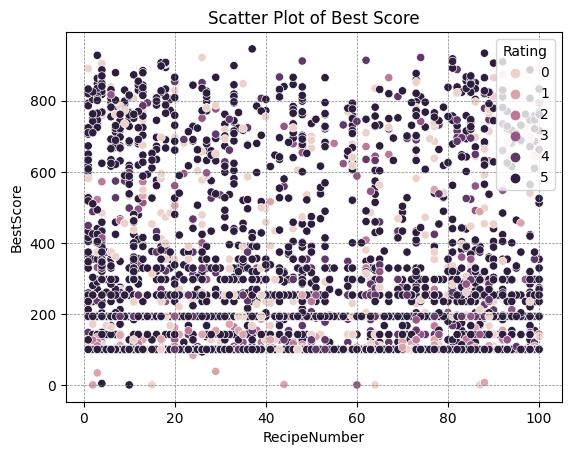

In [16]:
#Scatterplot of "BestScore" against "RecipeNumber"
exploration_set3=data.copy()
sns.scatterplot(x="RecipeNumber",y="BestScore",hue="Rating",data=exploration_set3)
plt.title('Scatter Plot of Best Score')
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.show()

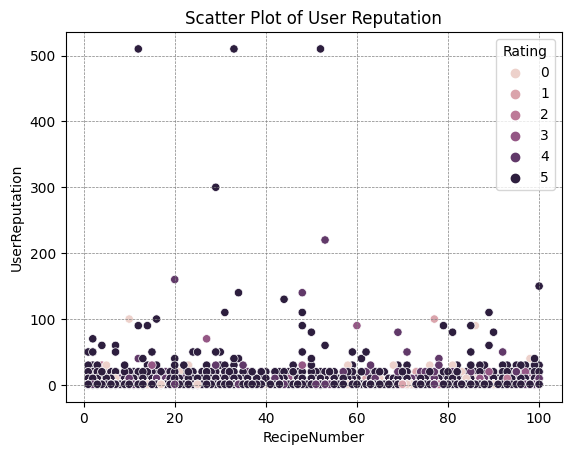

In [17]:
#Scatterplot of "UserReputation" against "RecipeNumber"
exploration_set4=data.copy()
sns.scatterplot(x="RecipeNumber",y="UserReputation",hue="Rating",data=exploration_set4)
plt.title('Scatter Plot of User Reputation')
plt.grid(True,linestyle="--",linewidth=0.5,color="gray")
plt.show()

<h5>There exists certain points in the numerical columns "ThumbsDownCount", "ThumbsUpCount", "BestScore and "UserReputation" that seem distant from the main cluster</h5>

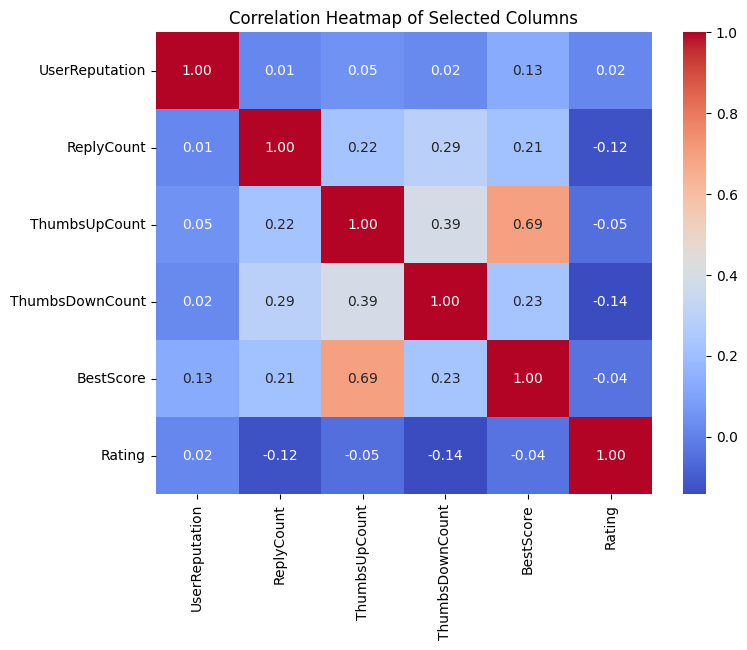

In [18]:
#Correlation analysis among certain columns
columns=["UserReputation","ReplyCount","ThumbsUpCount","ThumbsDownCount","BestScore","Rating"]
selected_columns=data[columns]
correlation=selected_columns.corr()
plt.figure(figsize=(8,6))
heatmap=sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap of Selected Columns")
plt.show()

<h5>There exists a strong positive correlation between the columns "BestScore" and "ThumbsUpCount" which may suggest that changes in one variable are associated with changes in another variable.</h5>

<h2>Data Cleaning and Preprocessing</h2>

In [19]:
#Copying the dataset into another variable
data2=data.copy()
data2.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


In [20]:
#Splitting the dataset into train and validation using Stratified Shuffle Split
stratified_split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,validation_index in stratified_split.split(data2,data2['Rating']):
    strat_train_set=data2.loc[train_index]
    strat_validation_set=data2.loc[validation_index]

In [21]:
#Finding the number of rows and columns present in the train and validation dataset
print("strat_train_set:",strat_train_set.shape)
print("strat_validation_set:",strat_validation_set.shape)

strat_train_set: (10908, 15)
strat_validation_set: (2728, 15)


<Axes: title={'center': 'strat_validation_set'}>

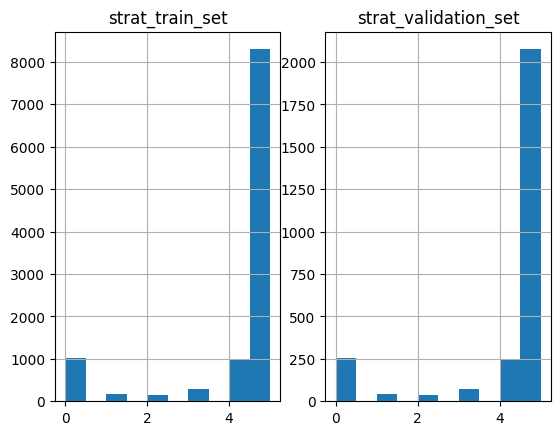

In [22]:
#To confirm if both the datasets have similar distribution
plt.subplot(1,2,1)
plt.title("strat_train_set")
strat_train_set['Rating'].hist()

plt.subplot(1,2,2)
plt.title("strat_validation_set")
strat_validation_set['Rating'].hist()

<h4>Preprocessing the train dataset</h4>

In [23]:
#Checking the dataset present in strat_train_set
strat_train_set.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
7291,397,2,3309,Best Ever Banana Bread,sp_aUSaElGf_3309_c_157899,u_1oKWwQIsTpdKNjZ0b2Dl5z1NWpN,Bama42,1,1622717127,0,0,0,5,100,I added chocolate chips and the taste was INCR...
9254,128,16,41101,Rustic Italian Tortellini Soup,sp_aUSaElGf_41101_c_111705,u_1oKVkNmC9eBELMlvEuIxuWIBnrG,vacicero,1,1622716902,0,1,0,5,193,Absolutely delicious!! The parmesan cheese ad...
5299,215,19,1693,Moist Chocolate Cake,sp_aUSaElGf_1693_c_283922,u_1oKaOphrUUFd3C141sBgHK3RzIa,tgeorge07,1,1622717768,0,0,0,0,100,The first day I received the Premiere Issue wi...
11252,143,64,12700,Big Soft Ginger Cookies,sp_aUSaElGf_12700_c_249712,u_1oKZFEG3isbjjOVGb5qFNcl72b3,colburnjl63,1,1622717589,0,0,0,5,100,My Family Loves Loves Lives TheseCookies! Eas...
13605,116,89,1324,Porcupine Meatballs,sp_aUSaElGf_1324_c_308921,u_1oKbF0DaqCkhgt8wvloKLsD9tc9,vickinboys,1,1622717899,0,0,0,5,100,This is a very good recipe. The only change I...


In [24]:
#Information about the train dataset.
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10908 entries, 7291 to 7194
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 10908 non-null  int64 
 1   RecipeNumber       10908 non-null  int64 
 2   RecipeCode         10908 non-null  int64 
 3   RecipeName         10908 non-null  object
 4   CommentID          10908 non-null  object
 5   UserID             10908 non-null  object
 6   UserName           10908 non-null  object
 7   UserReputation     10908 non-null  int64 
 8   CreationTimestamp  10908 non-null  int64 
 9   ReplyCount         10908 non-null  int64 
 10  ThumbsUpCount      10908 non-null  int64 
 11  ThumbsDownCount    10908 non-null  int64 
 12  Rating             10908 non-null  int64 
 13  BestScore          10908 non-null  int64 
 14  Recipe_Review      10907 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.3+ MB


In [25]:
#Removing the null values present in the train dataset.
strat_train_set.dropna(inplace=True)
strat_train_set.isna().sum()

ID                   0
RecipeNumber         0
RecipeCode           0
RecipeName           0
CommentID            0
UserID               0
UserName             0
UserReputation       0
CreationTimestamp    0
ReplyCount           0
ThumbsUpCount        0
ThumbsDownCount      0
Rating               0
BestScore            0
Recipe_Review        0
dtype: int64

<h5>Since the number of null values occuring in the dataset are few, its removal will not effect the final result.</h5>

In [26]:
#Removing data points that are distant from the main cluster in the train dataset
strat_train_set=strat_train_set.drop(strat_train_set[strat_train_set['ThumbsDownCount']>=40].index)
strat_train_set=strat_train_set.drop(strat_train_set[strat_train_set['ThumbsUpCount']>=50].index)
print(strat_train_set.shape)

(10886, 15)


<h4>Analysis was done to check the impact of model training with and without the data points that are distant from the main cluster.<br> 
It was found that the model works better when these data points are eliminated.<br> 
When working with the features from the "Recipe_Review" column after utilising the Tfidfvectorizer and SelectKBest, it was found that around 410 features were needed without removal of these distant points which caused the model to train for a long period of time.<br>
But after the elimination of these points only 250 features were required and the model took less time to train as well. It was also observed that the precision, recall and the f1-score improved after the removal of the distant points.</h4>

In [27]:
#Dropping certain features in the train dataset
strat_train_set.drop(["ID","RecipeNumber","RecipeCode","RecipeName","CommentID","UserID","UserName","CreationTimestamp","BestScore","UserReputation"],axis=1,inplace=True)
strat_train_set.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
7291,0,0,0,5,I added chocolate chips and the taste was INCR...
9254,0,1,0,5,Absolutely delicious!! The parmesan cheese ad...
5299,0,0,0,0,The first day I received the Premiere Issue wi...
11252,0,0,0,5,My Family Loves Loves Lives TheseCookies! Eas...
13605,0,0,0,5,This is a very good recipe. The only change I...


<h5>The columns "ReplyCount", "ThumbsUpCount", "ThumbsDownCount" and "Recipe_Review" are selected as they enabled to improve the model performance</h5>

In [28]:
#Reset the index for the train dataset
strat_train_set=strat_train_set.reset_index(drop=True)
strat_train_set.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
0,0,0,0,5,I added chocolate chips and the taste was INCR...
1,0,1,0,5,Absolutely delicious!! The parmesan cheese ad...
2,0,0,0,0,The first day I received the Premiere Issue wi...
3,0,0,0,5,My Family Loves Loves Lives TheseCookies! Eas...
4,0,0,0,5,This is a very good recipe. The only change I...


<h4>Making changes in the "Recipe_Review" column of the train dataset</h4>

In [29]:
#Storing the Recipe Review column in a variable
recipe_review=pd.DataFrame(strat_train_set["Recipe_Review"])
recipe_review.head()

,Recipe_Review
0,I added chocolate chips and the taste was INCR...
1,Absolutely delicious!! The parmesan cheese ad...
2,The first day I received the Premiere Issue wi...
3,My Family Loves Loves Lives TheseCookies! Eas...
4,This is a very good recipe. The only change I...


In [30]:
#Converting the text to lower case
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].str.lower()

#Removing the HTML tags
html_tags=lambda x:re.sub(r'<[^>]*>', '',str(x))
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].map(html_tags)

#Removing URLS
urls=lambda x:re.sub(r'http\S+', '', str(x))
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].map(urls)

In [31]:
#Removing contractions from the text
def remove(text):
    contractions={
      "ain't":"am not", "aren't":"are not",
      "can't":"cannot", "could've":"could have", "couldn't":"could not",
      "didn't":"did not", "doesn't":"does not", "don't":"do not",
      "hadn't":"had not","hasn't":"has not", "haven't":"have not",
      "he'd":"he had", "he'll":"he will", "he's":"he is",
      "how'd":"how did", "how'll":"how will", "how's":"how is",
      "I'd":"I had", "I'll":"I will", "I'm":"I am", "I've":"I have",
      "won't":"will not", "wouldn't":"would not"}
    for contraction, words in contractions.items():
        text=text.replace(contraction, words)
    return text

#Applying the function remove
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].apply(remove)

In [32]:
#Remove non-alpha characters
non_alpha=lambda x:re.sub("[^a-zA-Z]",' ',str(x))
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].map(non_alpha)

In [33]:
#Removing extra spaces
def remove_spaces(text):
    words=text.split()
    new_text=' '.join(words)
    return new_text

#Applying the function remove_spaces
recipe_review["Recipe_Review"]=recipe_review["Recipe_Review"].apply(remove_spaces)

In [34]:
#Creating a review list
reviews=recipe_review[["Recipe_Review"]]
review_list=reviews["Recipe_Review"].tolist()
review_list[:2]

['i added chocolate chips and the taste was incredible',
 'absolutely delicious the parmesan cheese added while the soup is served adds to the flavor the only change i made was to add more chicken broth cups of broth and omitted the water since the tortellini absorbs some of the liquid not enough liquid is left for leftovers if more broth is not added at the start']

In [35]:
#Creating a list of stop words and words that have to be excluded from the dataset
stop_words=list(ENGLISH_STOP_WORDS)+['amp','did','didn','don','ll','ve','said','wasn','hi','does','way','bit','won','tsp','doesn','oh']

In [36]:
#Finding the best min_df for the TfidfVectorizer to specify the minimum number of documents a term must appear in, to be included in the vocabulary.
pipeline=Pipeline([('tfidf',TfidfVectorizer(stop_words=stop_words)),('clf',MultinomialNB())])
parameters={'tfidf__min_df':[1,2,3,5,10,20,30,40,50,60,70,80,90,100]}

#Utilising the GridSearchCV to find the best min_df
grid_search=GridSearchCV(pipeline, parameters, cv=5, n_jobs=-1)
grid_search.fit(strat_train_set["Recipe_Review"],strat_train_set["Rating"])

best_min_df=grid_search.best_params_["tfidf__min_df"]
print("Best min_df:", best_min_df)

Best min_df: 30


In [37]:
#Utilising TfidfVectorizer on the review_list
vectorizer=TfidfVectorizer(min_df=30,stop_words=stop_words)
reviews_new=vectorizer.fit_transform(review_list)
reviews_new=pd.DataFrame.sparse.from_spmatrix(reviews_new, columns=vectorizer.get_feature_names_out())
reviews_new.head()

,able,absolute,absolutely,according,actually,add,added,adding,addition,additional,...,year,years,yeast,yellow,yes,yesterday,yogurt,yum,yummy,zucchini
0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.355848,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.153643,0.0,0.0,0.122126,0.217646,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.279464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.130069,0.115900,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
#Utilising SelectKBest to find the top 250 features from the "Recipe_Review" column
selector=SelectKBest(chi2, k=250).fit(reviews_new, strat_train_set["Rating"])
cols=selector.get_support(indices=True)
top_columns=reviews_new.iloc[:,cols]
top_columns=pd.DataFrame(top_columns.columns,columns=["Top 250 Features of Recipe_Review column"])
top_columns

,Top 250 Features of Recipe_Review column
0,absolutely
1,add
2,added
3,adding
4,additional
...,...
245,yeast
246,yes
247,yogurt
248,yummy


In [39]:
#Creating a dense array containing features from the "Recipe_Review" column
dense_array=reviews_new.iloc[:,cols].sparse.to_dense()
dense_array.columns=reviews_new.columns[cols].astype(str)
dense_array.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Columns: 250 entries, absolutely to zucchini
dtypes: float64(250)
memory usage: 20.8 MB


In [40]:
#Combining the strat_train_set and the dense_array
strat_train_set1=pd.concat([strat_train_set, dense_array], axis=1)
strat_train_set1=pd.DataFrame(strat_train_set1)
strat_train_set1.columns=strat_train_set1.columns.astype(str)
strat_train_set1.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review,absolutely,add,added,adding,additional,...,wow,written,wrong,year,years,yeast,yes,yogurt,yummy,zucchini
0,0,0,0,5,I added chocolate chips and the taste was INCR...,0.000000,0.000000,0.355848,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,0,5,Absolutely delicious!! The parmesan cheese ad...,0.153643,0.122126,0.217646,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,The first day I received the Premiere Issue wi...,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.279464,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,5,My Family Loves Loves Lives TheseCookies! Eas...,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,5,This is a very good recipe. The only change I...,0.000000,0.130069,0.115900,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
#Dropping the Recipe_Review column
strat_train_set1.drop("Recipe_Review", axis=1, inplace=True)
strat_train_set1.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,absolutely,add,added,adding,additional,ago,...,wow,written,wrong,year,years,yeast,yes,yogurt,yummy,zucchini
0,0,0,0,5,0.000000,0.000000,0.355848,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,0,5,0.153643,0.122126,0.217646,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.279464,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,5,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,5,0.000000,0.130069,0.115900,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
#Applying the Standard Scaler on the numerical columns that are "ThumbsDownCount", "ReplyCount", "ThumbsUpCount"
columns=["ThumbsDownCount","ReplyCount","ThumbsUpCount"]
scaler=StandardScaler()
strat_train_set1[columns]=scaler.fit_transform(strat_train_set1[columns])
strat_train_set2=pd.DataFrame(strat_train_set1, columns=strat_train_set1.columns)
strat_train_set2.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,absolutely,add,added,adding,additional,ago,...,wow,written,wrong,year,years,yeast,yes,yogurt,yummy,zucchini
0,-0.100073,-0.285819,-0.212267,5,0.000000,0.000000,0.355848,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.100073,-0.011055,-0.212267,5,0.153643,0.122126,0.217646,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.100073,-0.285819,-0.212267,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.279464,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.100073,-0.285819,-0.212267,5,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.100073,-0.285819,-0.212267,5,0.000000,0.130069,0.115900,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
#Separate features and labels of the train data
X_train=strat_train_set2.drop("Rating",axis=1)
y_train=strat_train_set2["Rating"].copy()

In [44]:
#Displaying the X_train shape and the y_train shape
print("X_train:",X_train.shape)
print("y_train:",y_train.shape)

X_train: (10886, 253)
y_train: (10886,)


<h4>Preprocessing the validation dataset</h4>

In [45]:
#Removing the null values present in the validation dataset
strat_validation_set.dropna(inplace=True)

In [46]:
#Dropping certain features in the train dataset
strat_validation_set.drop(["ID","RecipeNumber","RecipeCode","RecipeName","CommentID","UserID","UserName","CreationTimestamp","BestScore","UserReputation"],axis=1,inplace=True)

In [47]:
#Reset the index for the validation dataset
strat_validation_set=strat_validation_set.reset_index(drop=True)

<h4>Making changes in the "Recipe_Review" column of the validation dataset.</h4>

In [48]:
#Storing the Recipe Review column in a variable
recipe_review1=pd.DataFrame(strat_validation_set["Recipe_Review"])

In [49]:
#Converting the text to lower case
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].str.lower()

#Removing the HTML tags
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].map(html_tags)

#Removing URLS
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].map(urls)

#Applying the function remove to transform the contractions present in the text
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].apply(remove)

#Remove non-alpha characters
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].map(non_alpha)

#Removing spaces using the function remove_spaces
recipe_review1["Recipe_Review"]=recipe_review1["Recipe_Review"].apply(remove_spaces)

In [50]:
#Creating a review list
reviews1=recipe_review1[["Recipe_Review"]]
review_list1=reviews1["Recipe_Review"].tolist()

In [51]:
#Applying the TfidfVectorizer
reviews_new1=vectorizer.transform(review_list1)
reviews_new1=pd.DataFrame.sparse.from_spmatrix(reviews_new1, columns=vectorizer.get_feature_names_out())

In [52]:
#Applying the SelectKBest
selector.transform(reviews_new1)
cols_1=selector.get_support(indices=True)
top_columns_1=reviews_new1.iloc[:,cols_1]
top_columns_1=pd.DataFrame(top_columns_1.columns, columns=["Top 250 Features of Recipe_Review columns"])
top_columns_1

,Top 250 Features of Recipe_Review columns
0,absolutely
1,add
2,added
3,adding
4,additional
...,...
245,yeast
246,yes
247,yogurt
248,yummy


In [53]:
#Creating a dense array containing features from the "Recipe_Review" column
dense_array1=reviews_new1.iloc[:,cols_1].sparse.to_dense()
dense_array1.columns=reviews_new1.columns[cols_1].astype(str)
dense_array1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2727 entries, 0 to 2726
Columns: 250 entries, absolutely to zucchini
dtypes: float64(250)
memory usage: 5.2 MB


In [54]:
#Combining the strat_validation_set and the dense_array
strat_validation_set1=pd.concat([strat_validation_set, dense_array1], axis=1)
strat_validation_set1=pd.DataFrame(strat_validation_set1)
strat_validation_set1.columns=strat_validation_set1.columns.astype(str)

In [55]:
#Dropping the Recipe_Review column
strat_validation_set1.drop("Recipe_Review", axis=1, inplace=True)

In [56]:
#Applying the Standard Scaler on the numerical columns that are "ThumbsDownCount", "ReplyCount", "ThumbsUpCount"
columns1=["ThumbsDownCount","ReplyCount","ThumbsUpCount"]
scaler=StandardScaler()
strat_validation_set1[columns1]=scaler.fit_transform(strat_validation_set1[columns1])
strat_validation_set2=pd.DataFrame(strat_validation_set1, columns=strat_validation_set1.columns)

In [57]:
#Separate features and labels of the test data
X_test=strat_validation_set2.drop("Rating",axis=1)
y_test=strat_validation_set2["Rating"].copy()

In [58]:
#Displaying the X_test shape and the y_test shape
print("X_test:",X_test.shape)
print("y_test:",y_test.shape)

X_test: (2727, 253)
y_test: (2727,)


In [59]:
#Confirming the shape of train and test dataset
assert(X_train.shape[0]==y_train.shape[0])
assert(X_test.shape[0]==y_test.shape[0])

<h1>Baseline model</h1>

In [60]:
#Initialize and train a dummy classifier
dummy=DummyClassifier(strategy="most_frequent") #predicts the most_frequent class
dummy.fit(X_train,y_train)

#Making predictions
y_pred=dummy.predict(X_test)

#Evaluating the model
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy score of Dummy Classifier:",accuracy)

Accuracy score of Dummy Classifier: 0.7605427209387605


<h3>Model 1: Random Forest Classifier</h3>

In [61]:
RFC=RandomForestClassifier(random_state=42)

#Define hyperparameters
param_grid={"n_estimators":[50,100,200,300], #Number of trees in the forest
            "max_depth":[None,10,20], #Maximum depth of the tree
            "min_samples_leaf":[1,2,4] #Minimum number of samples required to be at a leaf node
}

#Applying GridSearchCV to find the best hyperparameters
grid_search1=GridSearchCV(RFC, param_grid, cv=5, scoring="accuracy")
grid_search1.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy')

In [62]:
#Printing the best parameters
best_params=grid_search1.best_params_
print("Best parameters:",best_params)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 50}


In [63]:
#Making prediction on the test dataset using the best parameters
best_estimator=grid_search1.best_estimator_
y_pred=best_estimator.predict(X_test)

In [64]:
#Printing the accuracy score, recall score, f1-score and precision score
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)

print("Accuracy of the Random Forest Classifier model:",accuracy)
print("Classification Report:\n",report)

Accuracy of the Random Forest Classifier model: 0.77007700770077
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.09      0.16       254
           1       0.50      0.05      0.09        42
           2       1.00      0.03      0.06        35
           3       0.31      0.05      0.09        74
           4       0.50      0.02      0.03       248
           5       0.78      1.00      0.87      2074

    accuracy                           0.77      2727
   macro avg       0.61      0.21      0.22      2727
weighted avg       0.72      0.77      0.69      2727



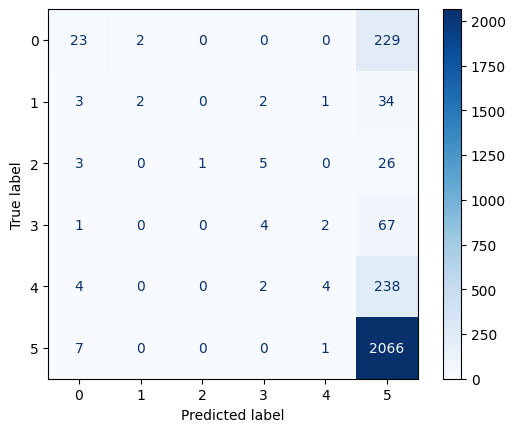

In [65]:
#Confusion matrix
cm=confusion_matrix(y_test,y_pred)
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap=plt.cm.Blues)
plt.show()

<h3>Model 2: Decision Tree Classifier</h3>

In [66]:
#dtc=DecisionTreeClassifier(random_state=42)

#param_grid={
    #"criterion":["gini","entropy"], #Measures the quality of the split
    #"max_depth":[None,10,20,30], #Maximum depth of the tree
    #"min_samples_split":[2,4,6,8,10], #Minimum samples required to split an internal node
    #"min_samples_leaf":[1,2,4], #Minimum number of samples required to be at leaf node
#}

#grid_search1=GridSearchCV(dtc, param_grid, cv=5, scoring="accuracy")
#grid_search1.fit(X_train,y_train)

In [67]:
#Printing the best parameters
#best_params=grid_search1.best_params_
#print("Best parameters:",best_params)

In [68]:
#Making prediction on the test dataset using the best parameters
#best_estimator=grid_search1.best_estimator_
#y_pred=best_estimator.predict(X_test)

In [69]:
#Printing the accuracy score, recall score, f1-score and precision score
#accuracy=accuracy_score(y_test,y_pred)
#report=classification_report(y_test,y_pred)

#print("Accuracy of the Decision Tree Classifier model:",accuracy)
#print("Classification Report:\n",report)

In [70]:
#Confusion matrix
#cm=confusion_matrix(y_test,y_pred)
#display=ConfusionMatrixDisplay(confusion_matrix=cm)
#display.plot(cmap=plt.cm.Blues)
#plt.show()

<h3>Model 3: K Neigbors Classifier</h3>

In [71]:
#knn_classifier=KNeighborsClassifier()
#param_grid={
    #"n_neighbors": [3,5,7], #Number of neighbors
    #"weights": ["uniform", "distance"], #Weights utilised in prediction
    #"algorithm":["auto", "ball_tree", "kd_tree", "brute"], # Algorithm used to compute the nearest neighbor
#}

#grid_search1=GridSearchCV(knn_classifier, param_grid, cv=5, scoring="accuracy")
#grid_search1.fit(X_train,y_train)

In [72]:
#Printing the best parameters
#best_params=grid_search1.best_params_
#print("Best parameters:",best_params)

In [73]:
#Making prediction on the test dataset using the best parameters
#best_estimator=grid_search1.best_estimator_
#y_pred=best_estimator.predict(X_test)

In [74]:
#Printing the accuracy score, recall score, f1-score and precision score
#accuracy=accuracy_score(y_test,y_pred)
#report=classification_report(y_test,y_pred)

#print("Accuracy of the KNeighbors Classifier model:",accuracy)
#print("Classification Report:\n",report)

In [75]:
#Confusion matrix
#cm=confusion_matrix(y_test,y_pred)
#display=ConfusionMatrixDisplay(confusion_matrix=cm)
#display.plot(cmap=plt.cm.Blues)
#plt.show()

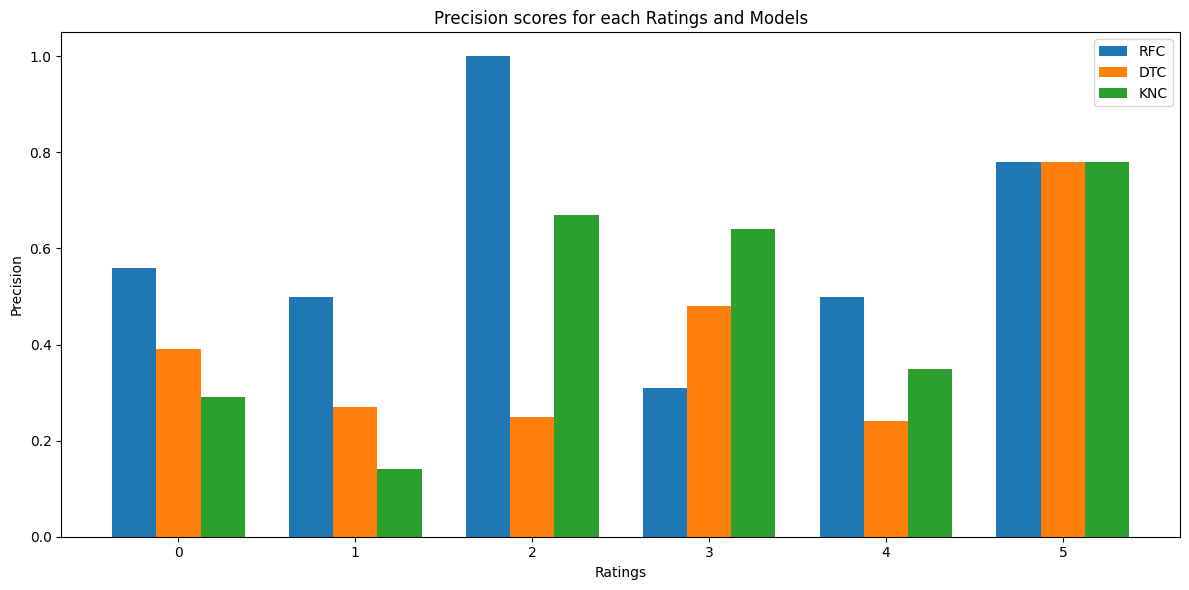

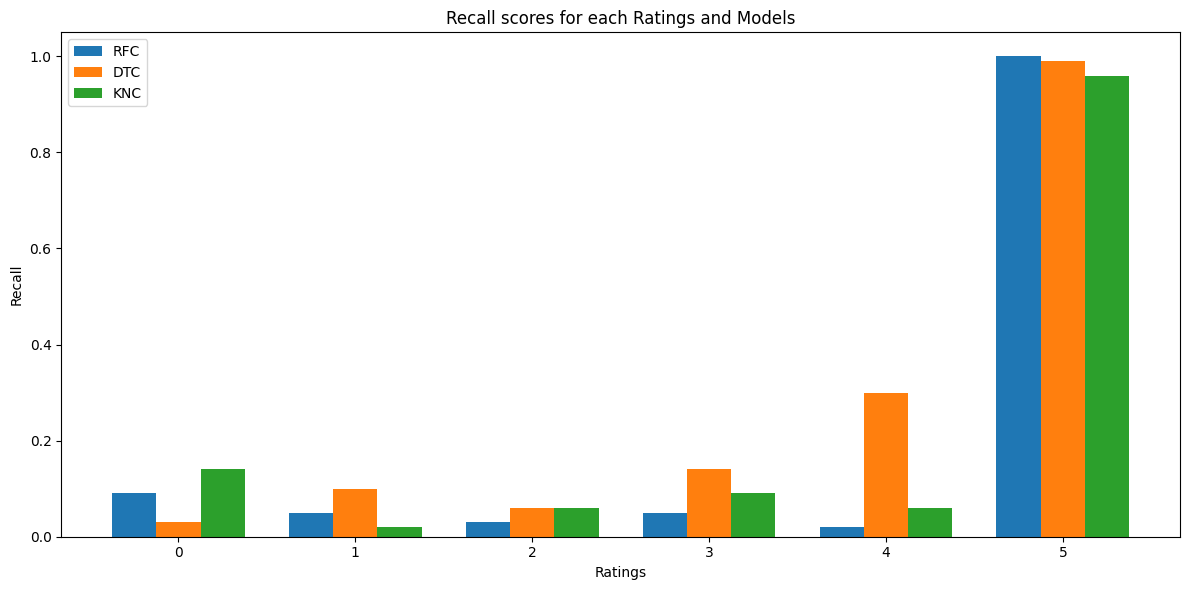

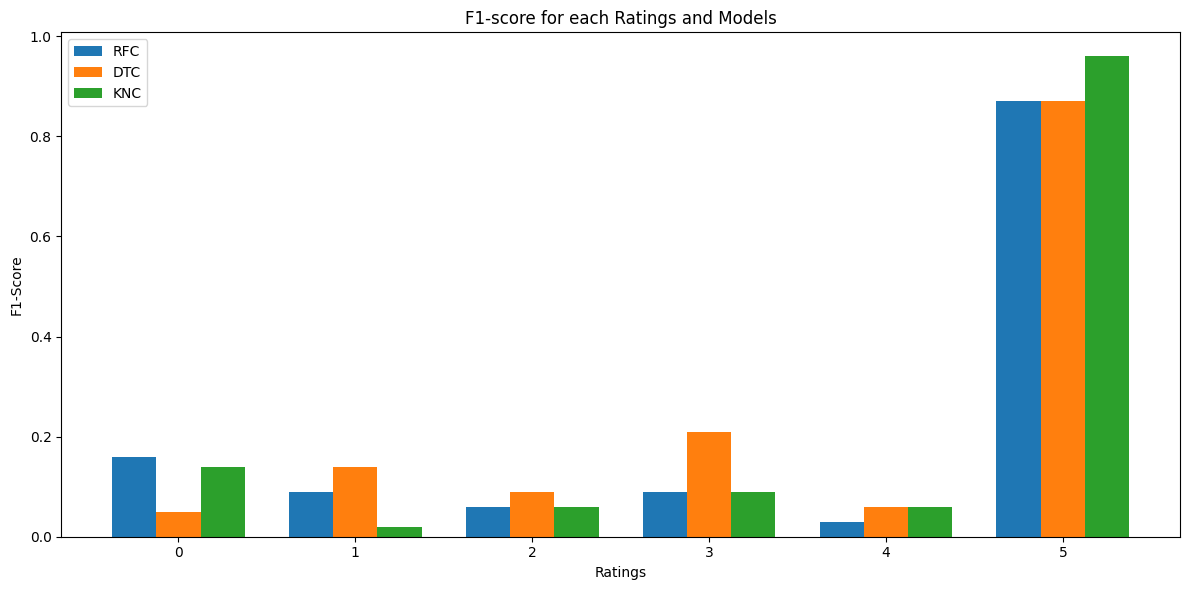

In [76]:
#Storing each model in a list
#RFC- Random Forest Classifier
#DTC- Decision Tree Classifier
#KNC- K Neighbors Classifier
models=["RFC","DTC","KNC"]

#Storing each target variable in a list
ratings=['0','1','2','3','4','5']

#Nested lists containing precision, recall and f1-score for each target variable and each model in nested lists
precision_scores=[[0.56,0.50,1.00,0.31,0.50,0.78],[0.39,0.27,0.25,0.48,0.24,0.78],[0.29,0.14,0.67,0.64,0.35,0.78]]
recall_scores=[[0.09,0.05,0.03,0.05,0.02,1.00],[0.03,0.10,0.06,0.14,0.30,0.99],[0.14,0.02,0.06,0.09,0.06,0.96]]
f1_scores=[[0.16,0.09,0.06,0.09,0.03,0.87],[0.05,0.14,0.09,0.21,0.06,0.87],[0.14,0.02,0.06,0.09,0.06,0.96]]

#Number of models and ratings
num_models=len(models)
num_ratings=len(ratings)

#Setting the positions for bars
ind=np.arange(num_ratings)

#Width of a bar
width=0.25

#Plotting precision scores for each model
plt.figure(figsize=(12,6))
for i in range(num_models):
    plt.bar(ind + i*width, precision_scores[i], width, label=models[i])

#Adding labels, title and legend
plt.xlabel("Ratings")
plt.ylabel("Precision")
plt.title("Precision scores for each Ratings and Models")
plt.xticks(ind + width * (num_models - 1) / 2, ratings)
plt.legend()
plt.tight_layout()
plt.show()

#Plotting recall scores for each model
plt.figure(figsize=(12,6))
for i in range(num_models):
    plt.bar(ind + i*width, recall_scores[i], width, label=models[i])

#Adding labels, title and legend
plt.xlabel("Ratings")
plt.ylabel("Recall")
plt.title("Recall scores for each Ratings and Models")
plt.xticks(ind + width * (num_models - 1) / 2, ratings)
plt.legend()
plt.tight_layout()
plt.show()

#Plotting f1-scores for each model
plt.figure(figsize=(12,6))
for i in range(num_models):
    plt.bar(ind + i*width, f1_scores[i], width, label=models[i])

#Adding labels, title and legend
plt.xlabel("Ratings")
plt.ylabel("F1-Score")
plt.title("F1-score for each Ratings and Models")
plt.xticks(ind + width * (num_models - 1) / 2, ratings)
plt.legend()
plt.tight_layout()
plt.show()

<h4><b>1. Accuracy score after training model using train dataset and predicting on the validation set:</b><br><br>
a. Random Forest Classifier: 0.7700<br><br>
b. Decision Tree Classifier: 0.7642<br><br>
c. K Neighbors Classifier: 0.751<br><br>
<b>2. Public Accuracy Scores for each model:</b><br><br>
a. Random Forest Classifier: 0.77078<br><br>
b. Decision Tree Classifier: 0.76286<br><br>
c. K Neighbors Classifier: 0.7567<br><br>
A precision score measures the proportion of true positive predictions among all positive predictions made the model.<br>
The recall score measures the proportions of true positive predictions among all the actual positive instances.<br>
The f1-score provides a harmonic between the precision and the recall score, that balances both the metrics. It takes both the false positive and false negative into account.<br>
The Random Forest Classifier has a higher precision score in all the classes in comparison with the Decision Tree Classifier and the K Neighbors Classifier.<br><br>
The Decision Tree Classifier and the K Neighbors Classifier seem to have higher recall score in comparison with the Random Forest Classifier. But for the Rating '5',which occurs most number of times in the dataset, the recall score of Random Forest Classifier is higher than the other two models.<br>
The Random Forest Classifier in comparison with the other two models not only achieved a good accuracy score after training the strat_train_set and predicting the trained model on the strat_validation_set but also achieved a good public score as shown above.<br><br>
All the three models are able to predict the minority classes.<br>
After trying all the three classifiers, the Random Forest Classifier model is selected.
</h4>

<h3>Preprocessing the whole train dataset</h3>

In [77]:
#Removing the null values present in the train dataset
data.dropna(inplace=True)
data.isna().sum()

ID                   0
RecipeNumber         0
RecipeCode           0
RecipeName           0
CommentID            0
UserID               0
UserName             0
UserReputation       0
CreationTimestamp    0
ReplyCount           0
ThumbsUpCount        0
ThumbsDownCount      0
Rating               0
BestScore            0
Recipe_Review        0
dtype: int64

In [78]:
#Removing certain points that seem distant from the main cluster
data=data.drop(data[data['ThumbsDownCount']>=40].index)
data=data.drop(data[data['ThumbsUpCount']>=50].index)
print(data.shape)

(13605, 15)


In [79]:
#Dropping certain features in the train dataset
data.drop(["ID","RecipeNumber","RecipeCode","RecipeName","CommentID","UserID","UserName","CreationTimestamp","BestScore","UserReputation"],axis=1,inplace=True)
data.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
0,0,0,0,5,great recipe! I have made them just as written...
1,0,0,1,5,This is an easy and quick recipe that is great...
2,0,0,0,3,I think I was looking for something extra spec...
3,0,0,0,5,This is our favorite grilled chicken recipe. ...
4,0,0,0,4,Great basic recipe. I added 2 teaspoons Tuscan...


In [80]:
#Reset the index for the train dataset
data=data.reset_index(drop=True)
data.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
0,0,0,0,5,great recipe! I have made them just as written...
1,0,0,1,5,This is an easy and quick recipe that is great...
2,0,0,0,3,I think I was looking for something extra spec...
3,0,0,0,5,This is our favorite grilled chicken recipe. ...
4,0,0,0,4,Great basic recipe. I added 2 teaspoons Tuscan...


<h4>Making changes in the Recipe Review column</h4>

In [81]:
#Storing the Recipe Review column in a variable
recipe_review2=pd.DataFrame(data["Recipe_Review"])
recipe_review2.head()

,Recipe_Review
0,great recipe! I have made them just as written...
1,This is an easy and quick recipe that is great...
2,I think I was looking for something extra spec...
3,This is our favorite grilled chicken recipe. ...
4,Great basic recipe. I added 2 teaspoons Tuscan...


In [82]:
#Converting the text to lower case
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].str.lower()

#Removing the HTML tags
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].map(html_tags)

#Removing URLS
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].map(urls)

#Applying the function remove to transform the contractions present in the text
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].apply(remove)

#Remove non-alpha characters
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].map(non_alpha)

#Removing spaces using the function remove_spaces
recipe_review2["Recipe_Review"]=recipe_review2["Recipe_Review"].apply(remove_spaces)

In [83]:
#Creating a review list
reviews2=recipe_review2[["Recipe_Review"]]
review_list2=reviews2["Recipe_Review"].tolist()

In [84]:
#Finding the best min_df for the TfidfVectorizer to specify the minimum number of documents a term must appear in to be included in the vocabulary.
pipeline=Pipeline([('tfidf',TfidfVectorizer(stop_words=stop_words)),('clf',MultinomialNB())])
parameters={'tfidf__min_df':[1,2,3,5,10,20,30,40,50,60,70,80,90,100]}

#Utilising the GridSearchCV to find the best min_df
grid_search=GridSearchCV(pipeline, parameters, cv=5, n_jobs=-1)
grid_search.fit(data["Recipe_Review"],data["Rating"])

best_min_df=grid_search.best_params_["tfidf__min_df"]
print("Best min_df:", best_min_df)

Best min_df: 40


In [85]:
#Utilising TfidfVectorizer on the review_list
vectorizer1=TfidfVectorizer(min_df=40,stop_words=stop_words)
reviews_new2=vectorizer1.fit_transform(review_list2)
reviews_new2=pd.DataFrame.sparse.from_spmatrix(reviews_new2, columns=vectorizer1.get_feature_names_out())
reviews_new2.head()

,able,absolute,absolutely,according,actually,add,added,adding,addition,additional,...,year,years,yeast,yellow,yes,yesterday,yogurt,yum,yummy,zucchini
0,0.0,0.0,0.0,0.0,0.0,0.0,0.158681,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.314379,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.167302,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.287735,0.0,0.0


In [86]:
#Utilising SelectKBest to find the top 270 features from the Recipe_Review column
selector1=SelectKBest(chi2, k=270).fit(reviews_new2, data["Rating"])
cols_2=selector1.get_support(indices=True)
top_columns_2=reviews_new2.iloc[:,cols_2]
top_columns_2=pd.DataFrame(top_columns_2.columns,columns=["Top 270 Features of Recipe_Review column"])
top_columns_2

,Top 270 Features of Recipe_Review column
0,able
1,absolutely
2,add
3,added
4,adding
...,...
265,years
266,yeast
267,yogurt
268,yum


In [87]:
#Creating a dense array containing features from the "Recipe_Review" column
dense_array2=reviews_new2.iloc[:,cols_2].sparse.to_dense()
dense_array2.columns=reviews_new2.columns[cols_2].astype(str)
dense_array2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605 entries, 0 to 13604
Columns: 270 entries, able to yummy
dtypes: float64(270)
memory usage: 28.0 MB


In [88]:
#Combining the strat_train_set and the dense_array
data_new=pd.concat([data, dense_array2], axis=1)
data_new=pd.DataFrame(data_new)
data_new.columns=data_new.columns.astype(str)
data_new.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review,able,absolutely,add,added,adding,...,wondering,wow,written,wrong,year,years,yeast,yogurt,yum,yummy
0,0,0,0,5,great recipe! I have made them just as written...,0.0,0.0,0.0,0.158681,0.0,...,0.0,0.0,0.261912,0.0,0.0,0.0,0.0,0.314379,0.000000,0.0
1,0,0,1,5,This is an easy and quick recipe that is great...,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0,0,0,3,I think I was looking for something extra spec...,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0,0,0,5,This is our favorite grilled chicken recipe. ...,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0,0,0,4,Great basic recipe. I added 2 teaspoons Tuscan...,0.0,0.0,0.0,0.167302,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.287735,0.0


In [89]:
#Dropping the Recipe_Review column
data_new.drop("Recipe_Review", axis=1, inplace=True)
data_new.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,able,absolutely,add,added,adding,additional,...,wondering,wow,written,wrong,year,years,yeast,yogurt,yum,yummy
0,0,0,0,5,0.0,0.0,0.0,0.158681,0.0,0.0,...,0.0,0.0,0.261912,0.0,0.0,0.0,0.0,0.314379,0.000000,0.0
1,0,0,1,5,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0,0,0,3,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0,0,0,5,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0,0,0,4,0.0,0.0,0.0,0.167302,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.287735,0.0


In [90]:
#Applying the Standard Scaler on the numerical columns that are "ThumbsDownCount", "ReplyCount", "ThumbsUpCount"
columns=["ThumbsDownCount","ReplyCount","ThumbsUpCount"]
scaler=StandardScaler()
data_new[columns]=scaler.fit_transform(data_new[columns])
data_new1=pd.DataFrame(data_new, columns=data_new.columns)
data_new1.head()

,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,able,absolutely,add,added,adding,additional,...,wondering,wow,written,wrong,year,years,yeast,yogurt,yum,yummy
0,-0.102039,-0.282941,-0.213994,5,0.0,0.0,0.0,0.158681,0.0,0.0,...,0.0,0.0,0.261912,0.0,0.0,0.0,0.0,0.314379,0.000000,0.0
1,-0.102039,-0.282941,0.260096,5,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,-0.102039,-0.282941,-0.213994,3,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,-0.102039,-0.282941,-0.213994,5,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,-0.102039,-0.282941,-0.213994,4,0.0,0.0,0.0,0.167302,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.287735,0.0


In [91]:
#Separate features and labels of the train dataset
X_final_data=data_new1.drop('Rating',axis=1)
y_final_data=data_new1['Rating'].copy()

In [92]:
#Displaying the X_final_data shape and the y_final_data shape
print("X_final_data:",X_final_data.shape)
print("y_final_data:",y_final_data.shape)

X_final_data: (13605, 273)
y_final_data: (13605,)


<h4>Applying the Random Forest Classifier</h4>

In [93]:
RFC=RandomForestClassifier(random_state=42)

#Define hyperparameters
param_grid={"n_estimators":[50,100,200,300], #Number of trees in the forest
            "max_depth":[None,10,20], #Maximum depth of the tree
            "min_samples_leaf":[1,2,4] #Minimum number of samples required to be at a leaf node
}

#Applying GridSearchCV to find the best hyperparameters
grid_search2 = GridSearchCV(RFC, param_grid, cv=5, scoring='accuracy')

#Fit the grid search to the training data
grid_search2.fit(X_final_data, y_final_data)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy')

In [94]:
prod_final_clf=grid_search2.best_estimator_

<h3>Preprocessing the kaggle test data</h3>

In [95]:
#Loading the data
test_data=pd.read_csv("/kaggle/input/recipe-for-rating-predict-food-ratings-using-ml/test.csv")

#Copying the dataset into another variable
test_data1=test_data.copy()

In [96]:
#Removing the null values present in the test dataset
test_data1.dropna(inplace=True)

In [97]:
#Dropping certain features in the test dataset
test_data1.drop(["ID","RecipeNumber","RecipeCode","RecipeName","CommentID","UserID","UserName","CreationTimestamp","BestScore","UserReputation"],axis=1,inplace=True)

In [98]:
#Reset the index for the test dataset
test_data1=test_data1.reset_index(drop=True)

<h4>Making changes in the "Recipe_Review" column of the test dataset</h4>

In [99]:
recipe_review3=pd.DataFrame(test_data1["Recipe_Review"])

#Converting the text to lower case
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].str.lower()

#Removing the HTML tags
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].map(html_tags)

#Removing URLS
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].map(urls)

#Applying the function remove to transform the contractions present in the text
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].apply(remove)

#Remove non-alpha characters
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].map(non_alpha)

#Removing spaces using the function remove_spaces
recipe_review3["Recipe_Review"]=recipe_review3["Recipe_Review"].apply(remove_spaces)

In [100]:
#Creating a review list
reviews3=recipe_review3[["Recipe_Review"]]
review_list3=reviews3["Recipe_Review"].tolist()

#Applying the TfidfVectorizer
reviews_new3=vectorizer1.transform(review_list3)
reviews_new3=pd.DataFrame.sparse.from_spmatrix(reviews_new3, columns=vectorizer1.get_feature_names_out())

In [101]:
#Applying the SelectKBest
selector1.transform(reviews_new3)
cols_3=selector1.get_support(indices=True)
top_columns_3=reviews_new3.iloc[:,cols_3]
top_columns_3=pd.DataFrame(top_columns_3.columns, columns=["Top 270 Features of Recipe_Review columns"])

In [102]:
#Creating a dense array containing features from the "Recipe_Review" column
dense_array3=reviews_new3.iloc[:,cols_3].sparse.to_dense()
dense_array3.columns=reviews_new3.columns[cols_3].astype(str)

In [103]:
#Combining the test data and the dense_array
test_data1=pd.concat([test_data1, dense_array3], axis=1)
test_data1=pd.DataFrame(test_data1)
test_data1.columns=test_data1.columns.astype(str)

In [104]:
#Dropping the Recipe_Review column
test_data1.drop("Recipe_Review", axis=1, inplace=True)

In [105]:
#Applying the Standard Scaler on the numerical columns that are "ThumbsDownCount", "ReplyCount", "ThumbsUpCount"
columns1=["ThumbsDownCount","ReplyCount","ThumbsUpCount"]
scaler=StandardScaler()
test_data1[columns1]=scaler.fit_transform(test_data1[columns1])
test_data2=pd.DataFrame(test_data1, columns=test_data1.columns)

In [106]:
# Make predictions on the test set
predictions = prod_final_clf.predict(test_data2)

In [107]:
submission=pd.DataFrame({"ID":range(1,4547),"Rating":predictions})
submission.to_csv('submission.csv',index=False)